# Random Forest Genre Classifier for FMA Small or Medium

This notebook builds a random forest genre classifier using the precomputed tabular audio features in `fma_metadata/features.csv` joined onto the cleaned per-split CSVs produced by [data_preprocessing.ipynb](data_preprocessing.ipynb).

Set `SUBSET` below to `"small"` (≈8 000 tracks, 8 genres) or `"medium"` (≈25 000 tracks, 16 genres). Both cleaned CSVs are produced by the preprocessing notebook — only the source data and the genre count differ.

Pipeline:

1. Resolve the project paths and load the chosen subset's per-split CSV from `fma_preprocessed/`.
2. Join each split onto the handcrafted FMA features to build the training, validation, and test matrices.
3. Optionally cap each split per genre to keep experiments manageable and balanced.
4. Train a random forest over one or more `n_estimators` settings.
5. Save the checkpoint with the best validation accuracy.
6. Evaluate the best model on the held-out test split.

If `fma_preprocessed/` is missing, run [data_preprocessing.ipynb](data_preprocessing.ipynb) first.

## 1. Setup

If the imports below fail in your Jupyter kernel, run this once in a notebook cell, restart the kernel, then continue:

```python
%pip install pandas numpy scikit-learn
```


In [27]:
from __future__ import annotations

import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Pick which cleaned FMA subset to train on. data_preprocessing.ipynb writes both.
SUBSET = "medium"  # or "medium"
if SUBSET not in {"small", "medium"}:
    raise ValueError("SUBSET must be either 'small' or 'medium'.")

# Resolve dataset paths by walking upward from the notebook working directory.
# This lets the notebook run from the repo root, code/, or code/random_forest/.
PROJECT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]

for candidate in PROJECT_CANDIDATES:
    features_path = candidate / "fma_metadata" / "features.csv"
    preprocessed_dir = candidate / "fma_preprocessed"
    if features_path.exists() and preprocessed_dir.exists():
        PROJECT_DIR = candidate.resolve()
        FEATURES_PATH = features_path.resolve()
        PREPROCESSED_DIR = preprocessed_dir.resolve()
        break
else:
    raise FileNotFoundError(
        "Could not find fma_metadata/features.csv and fma_preprocessed/ from the current "
        "directory or its ancestors. Run data_preprocessing.ipynb first to produce the "
        "cleaned per-split CSVs in fma_preprocessed/."
    )

RANDOM_FOREST_DIR = PROJECT_DIR / "code" / "random_forest"
RANDOM_FOREST_DIR.mkdir(parents=True, exist_ok=True)

print({
    "SUBSET": SUBSET,
    "PROJECT_DIR": str(PROJECT_DIR),
    "FEATURES_PATH": str(FEATURES_PATH),
    "PREPROCESSED_DIR": str(PREPROCESSED_DIR),
    "RANDOM_FOREST_DIR": str(RANDOM_FOREST_DIR),
})

{'SUBSET': 'medium', 'PROJECT_DIR': '/home/lily/acml-project', 'FEATURES_PATH': '/home/lily/acml-project/fma_metadata/features.csv', 'PREPROCESSED_DIR': '/home/lily/acml-project/fma_preprocessed', 'RANDOM_FOREST_DIR': '/home/lily/acml-project/code/random_forest'}


## 2. Load Preprocessed Splits + Features

The cleaning is already done by [data_preprocessing.ipynb](data_preprocessing.ipynb): it filtered to `fma_small`, dropped tracks with no genre, dropped undecodable MP3s, and removed the `FAILED` track ids from `creation.ipynb`. Here we just load each cleaned split and join on the handcrafted features the random forest consumes.

In [20]:
def flatten_columns(columns: pd.Index) -> list[str]:
    return ["__".join(str(part) for part in column) for column in columns]


# features.csv has a three-row header; flatten it once so every column is a single string.
features = pd.read_csv(FEATURES_PATH, index_col=0, header=[0, 1, 2])
features.columns = flatten_columns(features.columns)
features.index = features.index.astype(int)


def load_split(split: str) -> pd.DataFrame:
    """Read the cleaned per-split CSV for the chosen SUBSET and join on the handcrafted features."""
    split_path = PREPROCESSED_DIR / f"tracks_clean_{SUBSET}_{split}.csv"
    if not split_path.exists():
        raise FileNotFoundError(
            f"Missing {split_path}. Run data_preprocessing.ipynb to produce the "
            f"{SUBSET} CSVs."
        )
    frame = pd.read_csv(split_path)
    frame["track_id"] = frame["track_id"].astype(int)
    frame = frame.set_index("track_id")
    return frame.join(features, how="inner")


train_raw = load_split("training")
val_raw = load_split("validation")
test_raw = load_split("test")

# Concatenate for a quick post-cleaning summary.
metadata = pd.concat([train_raw, val_raw, test_raw])
metadata.head()

,subset,split,genre,duration,bit_rate,title,artist,audio_path,label,chroma_cens__kurtosis__01,...,tonnetz__std__04,tonnetz__std__05,tonnetz__std__06,zcr__kurtosis__01,zcr__max__01,zcr__mean__01,zcr__median__01,zcr__min__01,zcr__skew__01,zcr__std__01
track_id,,,,,,,,,,,,,,,,,,,,,
2,small,training,Hip-Hop,168,256000,Food,AWOL,/home/lily/acml-project/fma_small/000/000002.mp3,7,7.180653,...,0.054125,0.012226,0.012111,5.758890,0.459473,0.085629,0.071289,0.0,2.089872,0.061448
3,medium,training,Hip-Hop,237,256000,Electric Ave,AWOL,/home/lily/acml-project/fma_small/000/000003.mp3,7,1.888963,...,0.063831,0.014212,0.017740,2.824694,0.466309,0.084578,0.063965,0.0,1.716724,0.069330
5,small,training,Hip-Hop,206,256000,This World,AWOL,/home/lily/acml-project/fma_small/000/000005.mp3,7,0.527563,...,0.040730,0.012691,0.014759,6.808415,0.375000,0.053114,0.041504,0.0,2.193303,0.044861
10,small,training,Pop,161,192000,Freeway,Kurt Vile,/home/lily/acml-project/fma_small/000/000010.mp3,12,3.702245,...,0.074358,0.017952,0.013921,21.434212,0.452148,0.077515,0.071777,0.0,3.542325,0.040800
134,medium,training,Hip-Hop,207,256000,Street Music,AWOL,/home/lily/acml-project/fma_small/000/000134.mp3,7,0.918445,...,0.058766,0.016322,0.015819,4.731087,0.419434,0.064370,0.050781,0.0,1.806106,0.054623


In [21]:
# Non-feature columns inherited from tracks_clean.csv. Everything else is a feature.
METADATA_COLUMNS = {
    "subset", "split", "genre", "label",
    "duration", "bit_rate", "title", "artist", "audio_path",
}

print(f"Usable rows after preprocessing: {len(metadata):,}")
print(metadata["split"].value_counts())
print(metadata["genre"].value_counts().sort_index())
print(f"Feature columns: {sum(1 for c in metadata.columns if c not in METADATA_COLUMNS)}")

Usable rows after preprocessing: 25,000
split
training      19922
test           2573
validation     2505
Name: count, dtype: int64
genre
Blues                    74
Classical               619
Country                 178
Easy Listening           21
Electronic             6314
Experimental           2251
Folk                   1519
Hip-Hop                2201
Instrumental           1350
International          1018
Jazz                    384
Old-Time / Historic     510
Pop                    1186
Rock                   7103
Soul-RnB                154
Spoken                  118
Name: count, dtype: int64
Feature columns: 518


## 3. Pick a Manageable Balanced Split

The splits are already the official FMA ones. The caps below let you shrink each split per genre when you want a quicker experiment; leave them as `None` to use everything.

In [22]:
# These caps keep classes balanced while letting you shrink the experiment when needed.
MAX_TRAIN_PER_GENRE = None
MAX_EVAL_PER_GENRE = None


def cap_per_genre(frame: pd.DataFrame, max_per_genre: int | None) -> pd.DataFrame:
    if frame.empty:
        return frame.reset_index(drop=False)
    if max_per_genre is None:
        return frame.sample(frac=1, random_state=SEED).reset_index(drop=False)

    sampled_groups = [
        group.sample(min(len(group), max_per_genre), random_state=SEED)
        for _, group in frame.groupby("genre", sort=False)
    ]
    return (
        pd.concat(sampled_groups)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=False)
    )


train_df = cap_per_genre(train_raw, MAX_TRAIN_PER_GENRE)
val_df = cap_per_genre(val_raw, MAX_EVAL_PER_GENRE)
test_df = cap_per_genre(test_raw, MAX_EVAL_PER_GENRE)

# Prefer the genre_to_idx mapping written by data_preprocessing.ipynb so this notebook
# uses the same label ids as the CNN/transformer notebooks. Falls back to deriving from train.
genre_map_path = PREPROCESSED_DIR / f"genre_to_idx_{SUBSET}.csv"
if genre_map_path.exists():
    genre_map_df = pd.read_csv(genre_map_path)
    genre_to_idx = dict(zip(genre_map_df["genre"], genre_map_df["label"].astype(int)))
else:
    genres_sorted = sorted(train_df["genre"].unique())
    genre_to_idx = {g: i for i, g in enumerate(genres_sorted)}
idx_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}
genres = [idx_to_genre[i] for i in sorted(idx_to_genre)]

for frame in (train_df, val_df, test_df):
    frame["label"] = frame["genre"].map(genre_to_idx).astype(int)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(genre_to_idx)

Train: 19,922 | Val: 2,505 | Test: 2,573
{'Blues': 0, 'Classical': 1, 'Country': 2, 'Easy Listening': 3, 'Electronic': 4, 'Experimental': 5, 'Folk': 6, 'Hip-Hop': 7, 'Instrumental': 8, 'International': 9, 'Jazz': 10, 'Old-Time / Historic': 11, 'Pop': 12, 'Rock': 13, 'Soul-RnB': 14, 'Spoken': 15}


## 4. Build Tabular Matrices


In [23]:
def split_features_and_labels(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[str]]:
    feature_columns = [
        column
        for column in frame.columns
        if column not in METADATA_COLUMNS and column != "track_id"
    ]
    x = frame[feature_columns].to_numpy(dtype=np.float32)
    y = frame["label"].to_numpy(dtype=np.int64)
    return x, y, feature_columns


X_train, y_train, feature_columns = split_features_and_labels(train_df)
X_val, y_val, _ = split_features_and_labels(val_df)
X_test, y_test, _ = split_features_and_labels(test_df)

X_train.shape, X_val.shape, X_test.shape

((19922, 518), (2505, 518), (2573, 518))

## 5. Train the Random Forest

The cell below tries multiple forest sizes and keeps the model with the best validation accuracy.

`ccp_alpha` is the direct post-pruning control. `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes` also regularize tree growth and are usually the first knobs to tune.


In [24]:
# Tune these settings if you want to explore different random forest configurations.
N_ESTIMATOR_OPTIONS = [250]
MAX_DEPTH = 10
MAX_FEATURES = None
MIN_SAMPLES_SPLIT = 5
MIN_SAMPLES_LEAF = 1
MAX_LEAF_NODES = None
CCP_ALPHA = 0.0

best_val_acc = -1.0
best_model = None
best_n_estimators = None
history = []
best_model_path = RANDOM_FOREST_DIR / f"best_random_forest_{SUBSET}.pkl"

for n_estimators in N_ESTIMATOR_OPTIONS:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=MAX_DEPTH,
        max_features=MAX_FEATURES,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_leaf_nodes=MAX_LEAF_NODES,
        ccp_alpha=CCP_ALPHA,
        n_jobs=-1,
        random_state=SEED,
    )
    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    val_predictions = model.predict(X_val)
    train_acc = accuracy_score(y_train, train_predictions)
    val_acc = accuracy_score(y_val, val_predictions)

    history.append({
        "n_estimators": n_estimators,
        "train_acc": train_acc,
        "val_acc": val_acc,
    })

    print(
        f"n_estimators {n_estimators:4d} | "
        f"train acc {train_acc:.3f} | "
        f"val acc {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_n_estimators = n_estimators
        with best_model_path.open("wb") as handle:
            pickle.dump({
                "model": best_model,
                "genre_to_idx": genre_to_idx,
                "idx_to_genre": idx_to_genre,
                "feature_columns": feature_columns,
                "config": {
                    "subset": SUBSET,
                    "preprocessed_dir": str(PREPROCESSED_DIR),
                    "max_train_per_genre": MAX_TRAIN_PER_GENRE,
                    "max_eval_per_genre": MAX_EVAL_PER_GENRE,
                    "n_estimators": best_n_estimators,
                    "max_depth": MAX_DEPTH,
                    "max_features": MAX_FEATURES,
                    "min_samples_split": MIN_SAMPLES_SPLIT,
                    "min_samples_leaf": MIN_SAMPLES_LEAF,
                    "max_leaf_nodes": MAX_LEAF_NODES,
                    "ccp_alpha": CCP_ALPHA,
                    "seed": SEED,
                },
                "history": history,
            }, handle)

pd.DataFrame(history)

n_estimators  250 | train acc 0.774 | val acc 0.624


,n_estimators,train_acc,val_acc
0,250,0.773717,0.623553


## 5b. Hyperparameter Tuning

Sweep a grid of values for each random forest knob and pick the configuration with the best validation accuracy. Each completed configuration is appended to a JSONL resume log and mirrored to a CSV summary, so rerunning this cell skips configurations that already finished. Delete the saved tuning files if you want to restart the sweep from scratch.

In [31]:
import json
import time
from itertools import product

# Edit these grids to control the search space. Each list is the set of values to try for that hyperparameter.
PARAM_GRID = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 20, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 256],
    "ccp_alpha": [0.0, 1e-4],
}

# Always derive artifact paths from RANDOM_FOREST_DIR, even after partial reruns.
best_model_path = RANDOM_FOREST_DIR / f"best_random_forest_{SUBSET}.pkl"
best_val_acc = globals().get("best_val_acc", -1.0)
best_model = globals().get("best_model", None)
best_n_estimators = globals().get("best_n_estimators", None)
history = globals().get("history", [])
starting_best_val_acc = best_val_acc

tuning_log_path = RANDOM_FOREST_DIR / f"random_forest_tuning_results_{SUBSET}.jsonl"
tuning_results_path = RANDOM_FOREST_DIR / f"random_forest_tuning_results_{SUBSET}.csv"
tuned_model_path = RANDOM_FOREST_DIR / f"best_random_forest_tuned_{SUBSET}.pkl"
tuning_log_path.parent.mkdir(parents=True, exist_ok=True)

sweep_context = {
    "subset": SUBSET,
    "max_train_per_genre": MAX_TRAIN_PER_GENRE,
    "max_eval_per_genre": MAX_EVAL_PER_GENRE,
    "train_rows": int(len(X_train)),
    "val_rows": int(len(X_val)),
    "feature_count": int(len(feature_columns)),
}

param_names = list(PARAM_GRID.keys())
all_params = [dict(zip(param_names, values)) for values in product(*(PARAM_GRID[name] for name in param_names))]


def params_key(params: dict) -> str:
    return json.dumps(params, sort_keys=True)


def read_completed_results(path: Path) -> dict[str, dict]:
    completed_by_key = {}
    ignored_rows = 0
    grid_keys = {params_key(params) for params in all_params}

    if not path.exists():
        return completed_by_key

    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Skipping unreadable tuning log line {line_number} in {path}.")
                ignored_rows += 1
                continue

            required_columns = [*param_names, "train_acc", "val_acc"]
            if any(column not in record for column in required_columns):
                ignored_rows += 1
                continue
            if record.get("sweep_context") != sweep_context:
                ignored_rows += 1
                continue

            params = {name: record[name] for name in param_names}
            key = params_key(params)
            if key not in grid_keys:
                ignored_rows += 1
                continue

            record["train_acc"] = float(record["train_acc"])
            record["val_acc"] = float(record["val_acc"])
            completed_by_key[key] = record

    if ignored_rows:
        print(f"Ignored {ignored_rows} saved tuning row(s) that do not match the current grid.")
    return completed_by_key


def write_tuning_snapshot(records: list[dict]) -> pd.DataFrame:
    columns = [
        *param_names,
        "train_acc",
        "val_acc",
        "fit_seconds",
        "completed_at",
        "grid_index",
        "grid_total",
    ]

    if records:
        frame = pd.DataFrame(records)
        for column in columns:
            if column not in frame.columns:
                frame[column] = None
        frame = frame[columns].sort_values("val_acc", ascending=False).reset_index(drop=True)
    else:
        frame = pd.DataFrame(columns=columns)

    frame.to_csv(tuning_results_path, index=False)
    return frame


def checkpoint_payload(model: RandomForestClassifier, params: dict, val_acc: float, records: list[dict]) -> dict:
    return {
        "model": model,
        "genre_to_idx": genre_to_idx,
        "idx_to_genre": idx_to_genre,
        "feature_columns": feature_columns,
        "config": {
            "subset": SUBSET,
            "preprocessed_dir": str(PREPROCESSED_DIR),
            "max_train_per_genre": MAX_TRAIN_PER_GENRE,
            "max_eval_per_genre": MAX_EVAL_PER_GENRE,
            **params,
            "seed": SEED,
        },
        "history": history,
        "tuning_history": records,
        "tuned_val_acc": float(val_acc),
        "tuning_log_path": str(tuning_log_path),
        "tuning_results_path": str(tuning_results_path),
    }


def save_checkpoint(path: Path, model: RandomForestClassifier, params: dict, val_acc: float, records: list[dict]) -> None:
    with path.open("wb") as handle:
        pickle.dump(checkpoint_payload(model, params, val_acc, records), handle)


def checkpoint_matches_params(checkpoint: dict, params: dict) -> bool:
    config = checkpoint.get("config", {})
    return all(config.get(name) == value for name, value in params.items())


def promote_or_retrain_best(params: dict, val_acc: float, records: list[dict]) -> None:
    global best_model, best_val_acc, best_n_estimators

    checkpoint = None
    if tuned_model_path.exists():
        try:
            with tuned_model_path.open("rb") as handle:
                loaded_checkpoint = pickle.load(handle)
            if checkpoint_matches_params(loaded_checkpoint, params):
                checkpoint = loaded_checkpoint
            else:
                print(f"Saved tuned checkpoint at {tuned_model_path} does not match the current best params.")
        except Exception as exc:
            print(f"Could not load {tuned_model_path}: {exc}. Retraining the best params.")

    if checkpoint is None:
        print("Retraining the best saved tuning configuration so it can be promoted.")
        model = RandomForestClassifier(**params, n_jobs=-1, random_state=SEED)
        model.fit(X_train, y_train)
        save_checkpoint(tuned_model_path, model, params, val_acc, records)
        checkpoint = checkpoint_payload(model, params, val_acc, records)

    checkpoint["history"] = history
    checkpoint["tuning_history"] = records
    checkpoint["tuning_log_path"] = str(tuning_log_path)
    checkpoint["tuning_results_path"] = str(tuning_results_path)

    with best_model_path.open("wb") as handle:
        pickle.dump(checkpoint, handle)

    best_model = checkpoint["model"]
    best_val_acc = float(val_acc)
    best_n_estimators = params["n_estimators"]


completed_by_key = read_completed_results(tuning_log_path)
tuning_history = [completed_by_key[params_key(params)] for params in all_params if params_key(params) in completed_by_key]
completed_keys = set(completed_by_key)
tuning_results = write_tuning_snapshot(tuning_history)

print(f"Loaded {len(tuning_history)} completed configuration(s) from {tuning_log_path}.")
print(f"Running {len(all_params) - len(completed_keys)} remaining of {len(all_params)} configuration(s).")
print(f"CSV summary: {tuning_results_path}")

if tuning_history:
    best_record = max(tuning_history, key=lambda record: record["val_acc"])
    tuned_best_val_acc = float(best_record["val_acc"])
    tuned_best_params = {name: best_record[name] for name in param_names}
else:
    tuned_best_val_acc = -1.0
    tuned_best_params = None

for idx, params in enumerate(all_params, start=1):
    key = params_key(params)
    if key in completed_keys:
        continue

    model = RandomForestClassifier(
        **params,
        n_jobs=-1,
        random_state=SEED,
    )

    started_at = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started_at

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    record = {
        **params,
        "train_acc": float(train_acc),
        "val_acc": float(val_acc),
        "fit_seconds": round(fit_seconds, 3),
        "completed_at": pd.Timestamp.now().isoformat(),
        "grid_index": idx,
        "grid_total": len(all_params),
        "sweep_context": sweep_context,
    }
    candidate_history = [*tuning_history, record]

    if val_acc > tuned_best_val_acc:
        tuned_best_val_acc = float(val_acc)
        tuned_best_params = params
        save_checkpoint(tuned_model_path, model, params, val_acc, candidate_history)

    if val_acc > best_val_acc:
        save_checkpoint(best_model_path, model, params, val_acc, candidate_history)
        best_model = model
        best_val_acc = float(val_acc)
        best_n_estimators = params["n_estimators"]

    with tuning_log_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, sort_keys=True) + "\n")

    tuning_history.append(record)
    completed_keys.add(key)
    tuning_results = write_tuning_snapshot(tuning_history)

    print(
        f"[{idx:3d}/{len(all_params)}] "
        + " ".join(f"{name}={params[name]}" for name in param_names)
        + f" | train {train_acc:.3f} | val {val_acc:.3f} | saved"
    )

if not tuning_history:
    print("No tuning configurations have completed yet.")
else:
    best_record = max(tuning_history, key=lambda record: record["val_acc"])
    tuned_best_val_acc = float(best_record["val_acc"])
    tuned_best_params = {name: best_record[name] for name in param_names}

    if tuned_best_val_acc > best_val_acc:
        promote_or_retrain_best(tuned_best_params, tuned_best_val_acc, tuning_history)

    print("\nBest configuration from sweep:")
    for name, value in tuned_best_params.items():
        print(f"  {name}: {value}")
    print(f"  validation accuracy: {tuned_best_val_acc:.3f}")

    if tuned_best_val_acc > starting_best_val_acc:
        print(f"\nBest tuned model improves val acc {starting_best_val_acc:.3f} -> {tuned_best_val_acc:.3f}.")
        print(f"Best model checkpoint: {best_model_path}")
    else:
        print(f"\nNo tuned model beat the existing best ({starting_best_val_acc:.3f}); checkpoint unchanged.")

    print(f"Resume log: {tuning_log_path}")
    print(f"CSV summary: {tuning_results_path}")

tuning_results.head(10)

Loaded 1296 completed configuration(s) from /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.jsonl.
Running 0 remaining of 1296 configuration(s).
CSV summary: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.csv

Best configuration from sweep:
  n_estimators: 400
  max_depth: None
  max_features: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_leaf_nodes: None
  ccp_alpha: 0.0
  validation accuracy: 0.636

No tuned model beat the existing best (0.636); checkpoint unchanged.
Resume log: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.jsonl
CSV summary: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.csv


,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf,max_leaf_nodes,ccp_alpha,train_acc,val_acc,fit_seconds,completed_at,grid_index,grid_total
0,400,NaN,None,2,1,NaN,0.0000,0.999799,0.636327,324.334,2026-05-19T08:08:37.921945,1261,1296
1,200,20.0,None,2,2,NaN,0.0000,0.980725,0.635529,115.689,2026-05-18T21:28:05.900444,509,1296
2,200,NaN,None,10,1,NaN,0.0000,0.986598,0.634731,163.239,2026-05-18T23:12:47.247730,637,1296
3,300,20.0,None,2,2,NaN,0.0000,0.980825,0.634331,170.559,2026-05-19T01:06:43.292428,833,1296
4,200,NaN,None,2,2,NaN,0.0000,0.994930,0.634331,152.443,2026-05-18T22:33:57.451214,617,1296
5,200,20.0,None,2,2,NaN,0.0001,0.972242,0.633932,115.720,2026-05-18T21:30:02.104176,510,1296
6,400,20.0,None,2,2,NaN,0.0000,0.980825,0.633134,225.321,2026-05-19T06:15:37.531480,1157,1296
7,200,NaN,None,10,1,NaN,0.0001,0.962805,0.633134,162.498,2026-05-18T23:15:29.832512,638,1296
8,300,20.0,None,2,2,NaN,0.0001,0.972844,0.632735,170.210,2026-05-19T01:09:33.617163,834,1296
9,400,20.0,None,2,2,NaN,0.0001,0.973547,0.632735,225.118,2026-05-19T06:19:22.800480,1158,1296


## 6. Test Evaluation


In [32]:
# Reload the best validation checkpoint before measuring final test performance.
with best_model_path.open("rb") as handle:
    checkpoint = pickle.load(handle)

best_model = checkpoint["model"]
test_predictions = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_predictions)

print(f"Best validation accuracy: {best_val_acc:.3f} at n_estimators={best_n_estimators}")
print(f"Test accuracy: {test_acc:.3f}")


Best validation accuracy: 0.636 at n_estimators=400
Test accuracy: 0.590


## 7. Inspect Predictions


In [33]:
pd.DataFrame({
    "true": [idx_to_genre[int(label)] for label in y_test[:16]],
    "predicted": [idx_to_genre[int(prediction)] for prediction in test_predictions[:16]],
})


,true,predicted
0,Rock,Electronic
1,Hip-Hop,Hip-Hop
2,Electronic,Electronic
3,Hip-Hop,Hip-Hop
4,Classical,Instrumental
5,Experimental,Experimental
6,Electronic,Electronic
7,Electronic,Electronic
8,Rock,Rock
9,Rock,Rock


In [16]:
print("Classification report:")
print(classification_report(y_test, test_predictions, target_names=genres, digits=3))

confusion = confusion_matrix(y_test, test_predictions)
confusion_df = pd.DataFrame(confusion, index=genres, columns=genres)
confusion_df


Classification report:
               precision    recall  f1-score   support

   Electronic      0.496     0.570     0.530       100
 Experimental      0.292     0.260     0.275       100
         Folk      0.209     0.230     0.219       100
      Hip-Hop      0.560     0.650     0.602       100
 Instrumental      0.474     0.450     0.462       100
International      0.556     0.500     0.526       100
          Pop      0.459     0.390     0.422       100
         Rock      0.680     0.680     0.680       100

     accuracy                          0.466       800
    macro avg      0.466     0.466     0.464       800
 weighted avg      0.466     0.466     0.464       800



,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Pop,Rock
Electronic,57,3,1,16,5,2,14,2
Experimental,10,26,18,5,16,10,6,9
Folk,0,31,23,0,15,17,6,8
Hip-Hop,21,3,1,65,3,4,1,2
Instrumental,0,11,36,2,45,1,4,1
International,7,0,18,9,1,50,9,6
Pop,18,3,11,17,3,5,39,4
Rock,2,12,2,2,7,1,6,68


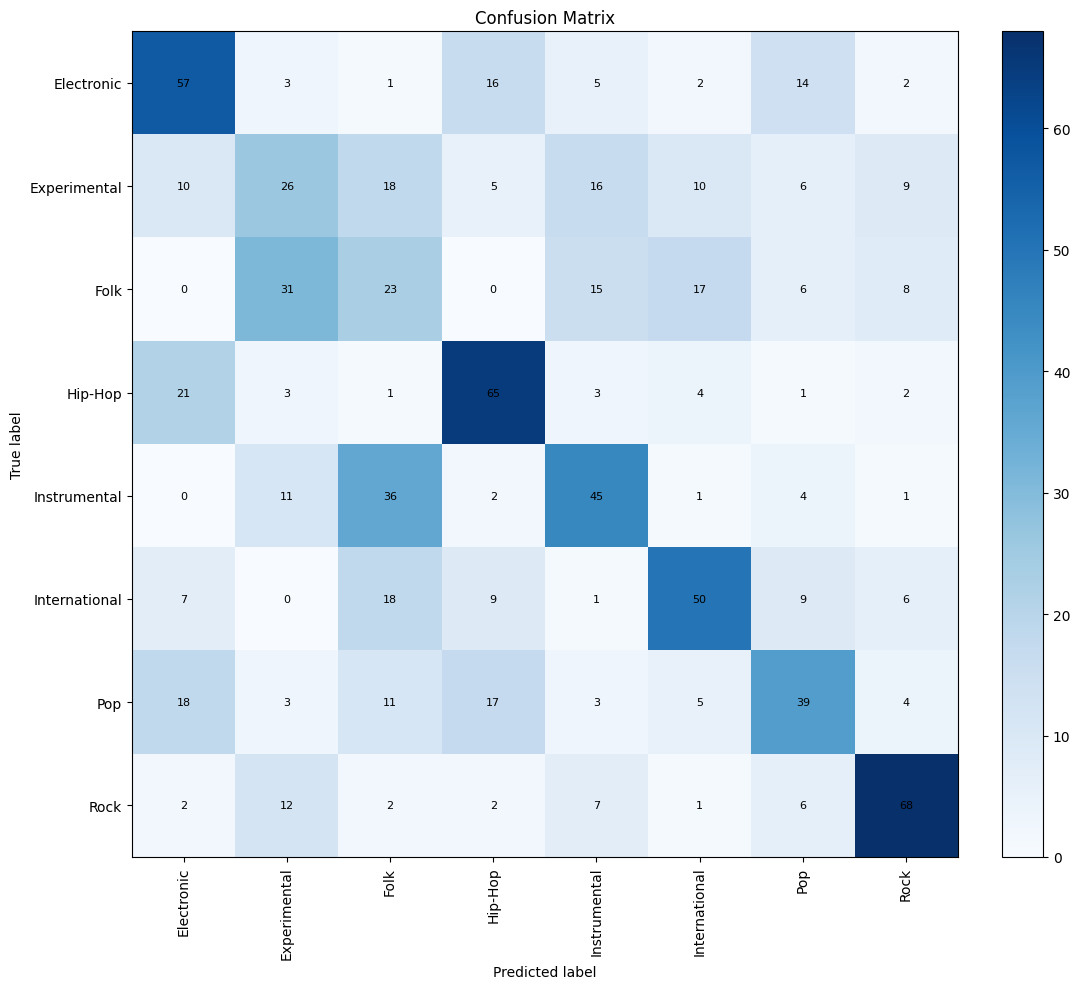

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(confusion, cmap="Blues")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(genres)))
ax.set_yticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=90)
ax.set_yticklabels(genres)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, confusion[i, j], ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
confusion_matrix_path = RANDOM_FOREST_DIR / f"confusion_matrix_random_forest_{SUBSET}.png"
fig.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix to {confusion_matrix_path}")
plt.show()
